In [1]:
from autogluon.tabular import TabularDataset, TabularPredictor
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [5]:
# Load and preprocess the data
df_ori = pd.read_excel(r'PA Concrete Database with GWP cement type 5.17.2024.xlsx', sheet_name='Sheet1')


# Define features and target
X_ori = df_ori[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values
y_ori = df_ori['GWP/strength'].values


# Step 1: Split the original data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X_ori, y_ori, train_size=0.8, random_state=42)

# Convert NumPy arrays to pandas DataFrame/Series for concatenation
Xtrain = pd.DataFrame(Xtrain, columns=['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 
                                          'AEA', 'WR_HR', 'WR', 'ACC', 'VOID', 'w/b', 'b/a', 'CAGG%', 
                                          'FAGG%', 'FA%', 'SS%', 'SF%'])
ytrain = pd.Series(ytrain, name='GWP/strength')

Xtest = pd.DataFrame(Xtest, columns = Xtrain.columns)
ytest = pd.Series(ytest, name = 'GWP/strength')

# Step 1: Combine features and target into a single DataFrame
train_data = pd.concat([Xtrain, ytrain], axis=1)

test_data = pd.concat([Xtest, ytest], axis=1)
# # Step 2: Split into training and test sets
# train_data, test_data = train_test_split(train_combined, test_size=0.2, random_state=42)

# Set the label (target) column
label = 'GWP/strength'  # The target column (compressive strength)

# Step 3: Train the AutoGluon model
predictor = TabularPredictor(label=label, problem_type='regression').fit(train_data, presets='best_quality')

# Step 4: Get a list of all model names from the leaderboard
all_models = predictor.get_model_names()

# Step 5: Collect metrics for each model
metrics = []
for model_name in all_models:
    y_pred = predictor.predict(test_data, model=model_name)
    r2 = r2_score(test_data[label], y_pred)
    rmse = np.sqrt(mean_squared_error(test_data[label], y_pred))
    mae = mean_absolute_error(test_data[label], y_pred)
    metrics.append({'Model': model_name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics)

print(metrics_df)




No path specified. Models will be saved in: "AutogluonModels/ag-20241015_024057"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.15
Operating System:   Darwin
Platform Machine:   x86_64
Platform Version:   Darwin Kernel Version 20.6.0: Wed Jun 23 00:26:31 PDT 2021; root:xnu-7195.141.2~5/RELEASE_X86_64
CPU Count:          8
Memory Avail:       4.66 GB / 16.00 GB (29.1%)
Disk Space Avail:   45.38 GB / 465.63 GB (9.7%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stac

[1000]	valid_set's rmse: 4.04469
[2000]	valid_set's rmse: 4.00169
[3000]	valid_set's rmse: 3.99545
[4000]	valid_set's rmse: 3.99297
[1000]	valid_set's rmse: 4.38216
[1000]	valid_set's rmse: 4.22522
[1000]	valid_set's rmse: 2.89865
[1000]	valid_set's rmse: 2.89643
[2000]	valid_set's rmse: 2.8782


	-3.5536	 = Validation score   (-root_mean_squared_error)
	22.33s	 = Training   runtime
	0.34s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 561.49s of the 860.94s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy


[1000]	valid_set's rmse: 3.91345
[2000]	valid_set's rmse: 3.88055
[1000]	valid_set's rmse: 4.51729
[1000]	valid_set's rmse: 3.21624
[1000]	valid_set's rmse: 4.18465


	-3.5555	 = Validation score   (-root_mean_squared_error)
	11.59s	 = Training   runtime
	0.17s	 = Validation runtime
Fitting model: RandomForestMSE_BAG_L1 ... Training model for up to 549.35s of the 848.8s of remaining time.
	-3.8201	 = Validation score   (-root_mean_squared_error)
	4.91s	 = Training   runtime
	0.26s	 = Validation runtime
Fitting model: CatBoost_BAG_L1 ... Training model for up to 543.82s of the 843.27s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
	-3.4714	 = Validation score   (-root_mean_squared_error)
	84.33s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: ExtraTreesMSE_BAG_L1 ... Training model for up to 459.38s of the 758.84s of remaining time.
	-3.8139	 = Validation score   (-root_mean_squared_error)
	1.26s	 = Training   runtime
	0.34s	 = Validation runtime
Fitting model: NeuralNetFastAI_BAG_L1 ... Training model for up to 457.5s of the 756.95s of remaining time.
	Fitting 8 child mode

...

[1000]	valid_set's rmse: 2.85345


	-3.1088	 = Validation score   (-root_mean_squared_error)
	14.3s	 = Training   runtime
	0.12s	 = Validation runtime
Fitting model: NeuralNetFastAI_r191_BAG_L2 ... Training model for up to 581.76s of the 581.59s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
/Users/zhangtianjie/opt/anaconda3/envs/autogluon/lib/python3.10/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they 

[1000]	valid_set's rmse: 3.08476
[1000]	valid_set's rmse: 3.46327
[1000]	valid_set's rmse: 3.53573
[1000]	valid_set's rmse: 2.76454
[1000]	valid_set's rmse: 3.24784
[1000]	valid_set's rmse: 2.97994
[2000]	valid_set's rmse: 2.94592
[3000]	valid_set's rmse: 2.94091
[4000]	valid_set's rmse: 2.93011
[5000]	valid_set's rmse: 2.93006


	-3.212	 = Validation score   (-root_mean_squared_error)
	8.01s	 = Training   runtime
	0.16s	 = Validation runtime
Fitting model: NeuralNetTorch_r22_BAG_L2 ... Training model for up to 311.37s of the 311.2s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
/Users/zhangtianjie/opt/anaconda3/envs/autogluon/lib/python3.10/site-packages/autogluon/tabular/models/tabular_nn/torch/tabular_nn_torch.py:411: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowe

                          Model        R2      RMSE       MAE
0         KNeighborsUnif_BAG_L1  0.614344  3.764608  2.508304
1         KNeighborsDist_BAG_L1  0.637848  3.648089  2.442866
2             LightGBMXT_BAG_L1  0.755329  2.998551  1.844047
3               LightGBM_BAG_L1  0.759078  2.975484  1.806527
4        RandomForestMSE_BAG_L1  0.696471  3.339793  2.097320
5               CatBoost_BAG_L1  0.760830  2.964650  1.779520
6          ExtraTreesMSE_BAG_L1  0.697245  3.335533  2.123793
7        NeuralNetFastAI_BAG_L1  0.664788  3.509778  2.258015
8                XGBoost_BAG_L1  0.769275  2.911836  1.763309
9         NeuralNetTorch_BAG_L1  0.698490  3.328672  2.141042
10         LightGBMLarge_BAG_L1  0.749559  3.033697  1.846676
11         CatBoost_r177_BAG_L1  0.762190  2.956208  1.776927
12    NeuralNetTorch_r79_BAG_L1  0.702294  3.307604  2.094519
13         LightGBM_r131_BAG_L1  0.756674  2.990298  1.793638
14  NeuralNetFastAI_r191_BAG_L1  0.682901  3.413636  2.171421
15      

In [15]:
# Load and preprocess the data
df = pd.read_excel(r'Coulomb data - ML 5.8.2024.xlsx', sheet_name='Grouped')
df.columns

# Define features and target
X = df[['AGE', 'PC1','PC2', 'PC1_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values
Y = df['COULOMB_TEST'].values

# x_mean = X.mean(0)
# x_std = X.std(0)
# X_normal = (X - x_mean) / x_std

# y_mean = Y.mean()
# y_std = Y.std()
# Y_normal = (Y - y_mean) / y_std



from scipy import stats
y_transformed, lam = stats.boxcox(Y)



# Step 1: Split the original data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, y_transformed, train_size=0.8, random_state=42)

# Convert NumPy arrays to pandas DataFrame/Series for concatenation
Xtrain = pd.DataFrame(Xtrain, columns=['AGE', 'PC1','PC2', 'PC1_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 
                                          'AEA', 'WR_HR', 'WR', 'ACC', 'VOID', 'w/b', 'b/a', 'CAGG%', 
                                          'FAGG%', 'FA%', 'SS%', 'SF%'])
ytrain = pd.Series(ytrain, name='COULOMB_TEST')

Xtest = pd.DataFrame(Xtest, columns = Xtrain.columns)
ytest = pd.Series(ytest, name = 'COULOMB_TEST')

# Step 1: Combine features and target into a single DataFrame
train_data = pd.concat([Xtrain, ytrain], axis=1)

test_data = pd.concat([Xtest, ytest], axis=1)
# # Step 2: Split into training and test sets
# train_data, test_data = train_test_split(train_combined, test_size=0.2, random_state=42)

# Set the label (target) column
label = 'COULOMB_TEST'  # The target column (compressive strength)

# Step 3: Train the AutoGluon model
predictor = TabularPredictor(label=label, problem_type='regression').fit(train_data, presets='best_quality')

# Step 4: Get a list of all model names from the leaderboard
all_models = predictor.get_model_names()

# Step 5: Collect metrics for each model
metrics = []
for model_name in all_models:
    y_pred = predictor.predict(test_data, model=model_name)
    r2 = r2_score(test_data[label], y_pred)
    rmse = np.sqrt(mean_squared_error(test_data[label], y_pred))
    mae = mean_absolute_error(test_data[label], y_pred)
    metrics.append({'Model': model_name, 'R2': r2, 'RMSE': rmse, 'MAE': mae})

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics)

print(metrics_df)




No path specified. Models will be saved in: "AutogluonModels/ag-20241015_040011"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.1.1
Python Version:     3.10.15
Operating System:   Darwin
Platform Machine:   x86_64
Platform Version:   Darwin Kernel Version 20.6.0: Wed Jun 23 00:26:31 PDT 2021; root:xnu-7195.141.2~5/RELEASE_X86_64
CPU Count:          8
Memory Avail:       4.93 GB / 16.00 GB (30.8%)
Disk Space Avail:   42.16 GB / 465.63 GB (9.1%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stac

[1000]	valid_set's rmse: 0.858021


	-0.7507	 = Validation score   (-root_mean_squared_error)
	12.19s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: CatBoost_r177_BAG_L1 ... Training model for up to 525.6s of the 825.65s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
	-0.7357	 = Validation score   (-root_mean_squared_error)
	6.45s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: NeuralNetTorch_r79_BAG_L1 ... Training model for up to 519.1s of the 819.16s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
/Users/zhangtianjie/opt/anaconda3/envs/autogluon/lib/python3.10/site-packages/autogluon/tabular/models/tabular_nn/torch/tabular_nn_torch.py:411: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code

[1000]	valid_set's rmse: 0.848512


	-0.7314	 = Validation score   (-root_mean_squared_error)
	5.42s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: NeuralNetFastAI_r191_BAG_L1 ... Training model for up to 485.95s of the 786.0s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
No improvement since epoch 14: early stopping
/Users/zhangtianjie/opt/anaconda3/envs/autogluon/lib/python3.10/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be al

...

[1000]	valid_set's rmse: 0.816951
[1000]	valid_set's rmse: 0.625026


	-0.7019	 = Validation score   (-root_mean_squared_error)
	12.02s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: NeuralNetFastAI_r172_BAG_L1 ... Training model for up to 1230.26s of the 1230.25s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
/Users/zhangtianjie/opt/anaconda3/envs/autogluon/lib/python3.10/site-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless th

[1000]	valid_set's rmse: 0.576927


	-0.7031	 = Validation score   (-root_mean_squared_error)
	4.81s	 = Training   runtime
	0.1s	 = Validation runtime
Fitting model: NeuralNetTorch_r1_BAG_L1 ... Training model for up to 797.86s of the 797.85s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy
/Users/zhangtianjie/opt/anaconda3/envs/autogluon/lib/python3.10/site-packages/autogluon/tabular/models/tabular_nn/torch/tabular_nn_torch.py:411: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowe

                         Model        R2      RMSE       MAE
0        KNeighborsUnif_BAG_L1  0.374990  0.756922  0.535124
1        KNeighborsDist_BAG_L1  0.416486  0.731363  0.511089
2            LightGBMXT_BAG_L1  0.519230  0.663859  0.477139
3              LightGBM_BAG_L1  0.513774  0.667616  0.486883
4       RandomForestMSE_BAG_L1  0.509229  0.670728  0.486121
..                         ...       ...       ...       ...
104         XGBoost_r34_BAG_L1  0.512226  0.668678  0.474446
105        LightGBM_r42_BAG_L1  0.515173  0.666654  0.471868
106   NeuralNetTorch_r1_BAG_L1  0.487533  0.685394  0.494305
107  NeuralNetTorch_r89_BAG_L1  0.465016  0.700289  0.501788
108        WeightedEnsemble_L2  0.537405  0.651190  0.465451

[109 rows x 4 columns]


In [43]:
print(metrics_df.to_string())

                           Model        R2      RMSE       MAE
0          KNeighborsUnif_BAG_L1  0.374990  0.756922  0.535124
1          KNeighborsDist_BAG_L1  0.416486  0.731363  0.511089
2              LightGBMXT_BAG_L1  0.519230  0.663859  0.477139
3                LightGBM_BAG_L1  0.513774  0.667616  0.486883
4         RandomForestMSE_BAG_L1  0.509229  0.670728  0.486121
5                CatBoost_BAG_L1  0.501652  0.675886  0.484662
6           ExtraTreesMSE_BAG_L1  0.538598  0.650350  0.458901
7         NeuralNetFastAI_BAG_L1  0.445231  0.713121  0.508340
8                 XGBoost_BAG_L1  0.504504  0.673950  0.486148
9          NeuralNetTorch_BAG_L1  0.486676  0.685967  0.488991
10          LightGBMLarge_BAG_L1  0.507785  0.671715  0.480798
11          CatBoost_r177_BAG_L1  0.498449  0.678055  0.487407
12     NeuralNetTorch_r79_BAG_L1  0.424782  0.726145  0.526314
13          LightGBM_r131_BAG_L1  0.529077  0.657025  0.473885
14   NeuralNetFastAI_r191_BAG_L1  0.429433  0.723204  0

In [40]:
import xgboost as xgb
from scipy.special import inv_boxcox
from sklearn.metrics import mean_squared_error
import numpy as np
# import matplotlib.pyplot as plt; plt.style.use('seaborn')
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
# from bayes_opt import BayesianOptimization
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

df = pd.read_excel(r'Coulomb data - ML 5.8.2024.xlsx', sheet_name='Sheet1')
df.columns

# Define features and target
X = df[['AGE', 'PC1','PC2', 'PC1_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values
Y = df['COULOMB_TEST'].values


from scipy import stats
Y, lam = stats.boxcox(Y)



y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

# Step 1: Split the original data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.8, random_state=42)

param_grid = {
    'max_depth': np.arange(3, 10, 1),
    'colsample_bytree': np.arange(0.5, 1.0, 0.1),
    'gamma': np.arange(0, 0.5, 0.1),
    'learning_rate': np.arange(0.01, 0.1, 0.01),
    'n_estimators': [100, 200, 300, 400, 500]
}

xgb = XGBRegressor(objective='reg:squarederror')

random_search = RandomizedSearchCV(xgb, param_distributions=param_grid, n_iter=50, scoring='neg_mean_squared_error', cv=3, verbose=3, random_state=42, n_jobs=24)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
predictions = best_xgb.predict(X_test)


# Step 1: Reverse the standardization process for predictions
predictions_reversed = (predictions * y_std) + y_mean

# Step 2: Reverse the standardization for y_test values
y_test_reversed = (y_test * y_std) + y_mean

# Step 3: Inverse Box-Cox transformation of the predictions and y_test
predictions_original_scale = inv_boxcox(predictions_reversed, lam)
y_test_original_scale = inv_boxcox(y_test_reversed, lam)

mse = mean_squared_error(y_test_original_scale, predictions_original_scale)

print("Best estimator: ", best_xgb)
print("Best parameters: ", random_search.best_params_)
print("Best validation score: ", random_search.best_score_)
print("MSE on test data: ", mse)
print(best_xgb.score(X_train, y_train))
print(best_xgb.score(X_test, y_test))

# Calculate the R² score using the original scale
r2_original = metrics.r2_score(y_test_original_scale, predictions_original_scale)

# Print the R² score
print("R² on the original scale: ", r2_original)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best estimator:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.04, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)
Best parameters:  {'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.04, 'gamma': 0.0, 'colsample_bytree': 0.5}
Best validation score:  -8.79028761442705
MSE on test data:  1

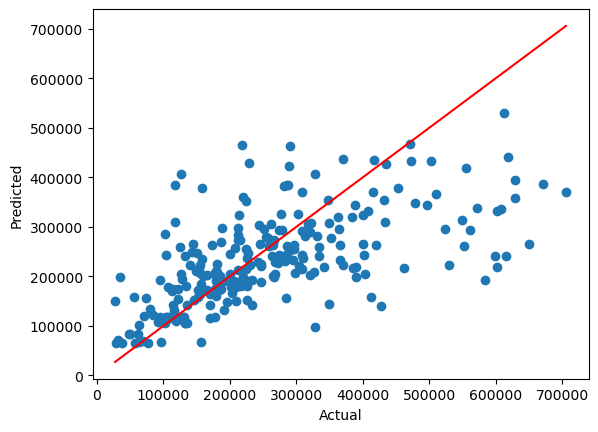

[CV 3/3] END colsample_bytree=0.7999999999999999, gamma=0.2, learning_rate=0.02, max_depth=3, n_estimators=100;, score=-3.070 total time=   0.3s
[CV 3/3] END colsample_bytree=0.5, gamma=0.1, learning_rate=0.05, max_depth=5, n_estimators=200;, score=-2.649 total time=   0.8s
[CV 3/3] END colsample_bytree=0.7, gamma=0.0, learning_rate=0.09, max_depth=5, n_estimators=500;, score=-2.894 total time=   2.3s
[CV 3/3] END colsample_bytree=0.8999999999999999, gamma=0.0, learning_rate=0.04, max_depth=6, n_estimators=100;, score=-2.579 total time=   0.9s
[CV 3/3] END colsample_bytree=0.7999999999999999, gamma=0.0, learning_rate=0.04, max_depth=5, n_estimators=400;, score=-2.756 total time=   1.9s
[CV 3/3] END colsample_bytree=0.8999999999999999, gamma=0.4, learning_rate=0.09, max_depth=4, n_estimators=500;, score=-2.695 total time=   0.8s
[CV 1/3] END colsample_bytree=0.5, gamma=0.0, learning_rate=0.060000000000000005, max_depth=5, n_estimators=500;, score=-2.639 total time=   1.3s
[CV 3/3] END c

In [41]:
import matplotlib.pyplot as plt
plt.scatter(y_test_original_scale, predictions_original_scale)
plt.xlabel('Actual')
plt.ylabel('Predicted')
# Adding the y = x line (perfect prediction line)
min_val = min(min(y_test_original_scale), min(predictions_original_scale))
max_val = max(max(y_test_original_scale), max(predictions_original_scale))
plt.plot([min_val, max_val], [min_val, max_val], color='red', label='y = x')

